<a href="https://colab.research.google.com/github/MamoMGD1/ML_101/blob/main/notebooks/Section01/Chapter02_k_Nearest_Neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**k-NEAREST NEIGHBORS**

## **Non-Parametric Models**

So far, all the algorithms we’ve studied for both **regression** and **classification** have been **parametric models**. These models *learn* from the data we feed them — a training process that tunes their internal **parameters** (like weights and biases) to best fit the patterns in the training dataset. Once trained, these parameters allow the model to make predictions for new, unseen data.

This approach is powerful and precise — but it comes with a limitation: **parametric models need large, diverse training datasets** to find meaningful patterns. Without enough quality data, they risk underfitting or learning misleading patterns.

But what happens when we *don’t* have lots of data — or when we’d rather not spend time training parameters at all?
That’s where **non-parametric models** come in. These models skip the training step entirely — they store the data you give them and predict directly by comparing new inputs to what they’ve already seen. There are no learned weights or equations — only **similarity** and **proximity**.

A classic and widely-used example of this approach is **k-Nearest Neighbors (KNN)**. Whether for regression or classification, KNN uses the idea that similar inputs should have similar outputs — so it looks at the *k* closest data points and lets them decide.

In this chapter, we’ll see how this simple idea can solve powerful problems — and why sometimes, **learning nothing upfront** can still give you reasonable predictions.

## **Concept of Similarity**

When using **k-Nearest Neighbors**, we need a way to measure how *similar* or *close* two samples are. But how do we define "similarity"?

Previously, we learned about **cosine similarity**, which checks how *aligned* two vectors are — it measures the *angle* between them. If two vectors point in the same direction, their cosine similarity is close to `1`; if they are orthogonal (perpendicular), it’s `0`; if they point in opposite directions, it’s `-1`. Cosine similarity cares about *direction*, not *magnitude*.

On the other hand, in KNN, we usually care about the *absolute distance* between points — we want to know how *far* or *close* they are in feature space. This is where distance metrics like **Manhattan**, **Euclidean**, or more generally, **Minkowski distance** come in.

The **Minkowski distance** is a flexible distance metric defined by:

$$
D(x, y) = \Bigg( \sum_{i=1}^{n} |x_i - y_i|^p \Bigg)^{1/p}
$$

* If **p = 1**, it becomes the **Manhattan distance** (like moving along city blocks).
* If **p = 2**, it becomes the **Euclidean distance** (straight-line distance).
* As **p →** $\infty$, it becomes the **Chebyshev distance**, which only considers the largest single difference.

**Different p-values change how we weigh dimensions:**

* Lower *p* means every dimension’s difference contributes more linearly.
* Higher *p* means large individual differences dominate.

In practice, **Euclidean (p=2)** is the most common for KNN because it balances dimensions naturally.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S01_C02/distance.png" width="500">
</div>

### **When to use cosine vs. Minkowski**

While cosine similarity is excellent when *direction* matters more than length — like comparing text documents where word frequency vectors can have wildly different magnitudes — it’s not often used for KNN on numeric feature spaces. Why?

Because in most real-world structured datasets (like measurements, pixel values, sensor data), *magnitude* is meaningful: two vectors pointing in the same direction but with vastly different sizes should *not* be considered identical.

Therefore, for KNN, we almost always prefer distance metrics like Minkowski or Euclidean that take both *direction* and *magnitude* into account — ensuring that "closeness" truly reflects similarity in all dimensions.

Understanding this difference helps us choose the right metric for the data and ensures that our KNN models make meaningful predictions based on the type of similarity that really matters.

## **KNN Algorithm**

The **k-Nearest Neighbors (KNN)** algorithm is a **non-parametric, instance-based learning method**. Unlike models such as linear regression or logistic regression that estimate parameters during training, KNN has **no explicit training phase**. Instead, it stores the training data and makes predictions directly at query time. This is why KNN is often called a **“lazy learner.”**

For a new sample (point) that we want to predict:
1. Compute the **distance** between this sample and every data point in the training set.  
   - Common choices are **Euclidean distance**, **Manhattan distance**, or any other variations of **Minkowski distance**.  
   - The choice of distance metric can significantly affect performance.
2. Select the **k closest points** (neighbors).  
   - The value of `k` controls the bias-variance tradeoff.  
   - Small `k` → very sensitive to local variations (risk of overfitting).  
   - Large `k` → smoother predictions, but may underfit.
3. Make the prediction:  
   - **Classification:** Take the **mode** (majority vote) of the neighbors’ labels.  
   - **Regression:** Take the **mean** of the neighbors’ values.

This way, KNN **learns by proximity** rather than through parameters or explicit training.

---

### **Important Considerations**

- **Feature Scaling Matters:** Since KNN relies on distance calculations, features with larger scales can dominate the metric. Normalization or standardization is usually required.  
- **Handling Ties:** If two classes appear equally often among neighbors, tie-breaking strategies are needed (e.g., picking the class of the closest neighbor).  
- **Weighted KNN:** Instead of treating all neighbors equally, we can assign weights inversely proportional to distance. This way, closer points influence the prediction more strongly.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def minkowski_distance(x, y, p=2):
    return np.sum(np.abs(x - y)**p, axis=1)**(1/p)

def knn(X, y, sample, k=5, mode='classifier'):
    """
    k-Nearest Neighbors prediction for classification or regression.

    Args:
        X (array): Training feature matrix
        y (array): Training labels/targets
        sample (array): Single sample to predict
        k (int): Number of nearest neighbors to consider
        mode (str): 'classifier' or 'regressor'

    Returns:
        Predicted label (classification) or value (regression) for sample
    """
    # Calculate distances from sample to all training points
    distances = minkowski_distance(X, sample)

    # Create dataframe with labels and distances
    df = pd.DataFrame({'Label': y, 'Distance': distances})

    # Get k nearest neighbors (smallest distances)
    k_nearest = df.nsmallest(k, 'Distance')

    # For regression: return average of k nearest labels
    if mode == 'regressor':
        return k_nearest['Label'].mean()

    # For classification: return most frequent label among k nearest
    # If there's a tie, mode()[0] returns the first (nearest due to sorting)
    return k_nearest['Label'].mode()[0]

## **Performance Metrics**

In regression problems we already saw many performance metrics and loss functions. The goal there was simple: measure **how far** our predictions are from the real values. Since outputs are continuous, we could use functions like MSE or MAE to capture the average "closeness" of predictions.

But classification is different. Here, the outputs are **discrete labels** — predictions are either **right** or **wrong**. Because of this, regression-style metrics that depend on *distance* make no sense. We need a different way to judge performance.

One option we’ve seen is **cross-entropy loss**. It works beautifully for models that output probabilities (like logistic regression or neural networks), punishing confident but wrong predictions more heavily than uncertain ones. However, not all models provide probabilities — think of KNN, which simply counts votes among neighbors. In such cases, cross-entropy can’t be applied.

This leads us to simpler, count-based approaches. A natural first idea is to look at the **error rate**: the ratio of misclassified samples to the total number of samples. If fewer mistakes are made, the model is better. Easy enough, right?

Well, not always. Imagine a dataset with 1000 animals: 990 dogs and just 10 cats. A lazy model that predicts *“dog” for everything* would be wrong only 10 times. That’s an error rate of just **1%**, which looks amazing on paper — but in reality, the model has completely failed to learn the concept of “cat.”

This example shows that a single error rate isn’t enough to capture the whole story. For real-world problems, especially with imbalanced data, we need more nuanced performance metrics. Before we get there, let’s carefully define some basic building blocks: **True Positives, True Negatives, False Positives, and False Negatives.**

### **Essential Terms**

To evaluate a classification model, let's go on with an **HIV test:** We test a model on **200 people**:
- **100 truly HIV+ (sick)**  
- **100 truly HIV- (healthy)**  

The model predictions come out like this:
- Among the 100 sick people → 80 labeled HIV+, 20 labeled HIV-.  
- Among the 100 healthy people → 60 labeled HIV-, 40 labeled HIV+.  

Now let’s carefully define these terms:

1. **True Positive:** Out of 100 truly HIV+ cases, our model has classified 80 as HIV+. So in 80 cases the model said positive and it was true, that's why we call its **True Positive (TP) = 80**.  

2. **True Negative:** Out of 100 truly HIV- cases, our model has classified 60 as HIV-. So in 60 cases the model said negative and it was true, that's why we call it **True Negative (TN) = 60**.  

3. **False Negative:** Out of 100 truly HIV+ cases, our model has classified 20 as HIV-. So in 20 cases the model said negative and it was false, that's why we call it **False Negative (FN) = 20**.  

4. **False Positive:** Out of 100 truly HIV- cases, our model has classified 40 as HIV+. So in 40 cases the model said positive and it was false, that's why we call it **False Positive (FP) = 40**.  

So:
- **TP** → Correctly predicted “yes.”  
- **TN** → Correctly predicted “no.”  
- **FP** → Predicted “yes” but it was wrong.  
- **FN** → Predicted “no” but it was wrong.  

#### **Fire Alarm Example**

*Now let's apply the same logic to the images below from a fire alarm system.*

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S01_C02/alarm.png" width="600">
</div>

- **True Positive (TP):** The total number of times there was a real fire and the alarm went off.  
- **True Negative (TN):** The total number of times there was no fire and the alarm stayed silent.  
- **False Negative (FN):** The total number of times there was a real fire but the alarm stayed silent.  
- **False Positive (FP):** The total number of times there was no fire but the alarm rang anyway.  

#### **Shepherd Dog Example**

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S01_C02/dog.png" width="550">
</div>

- **True Positive (TP):** The total number of times a wolf appeared and the dog attacked it.  
- **True Negative (TN):** The total number of times a sheep appeared and the dog ignored it.  
- **False Negative (FN):** The total number of times a wolf appeared but the dog let it pass.  
- **False Positive (FP):** The total number of times a sheep appeared but the dog attacked it.  

#### **Ultimate Aim**

Always remember: in classification problems, our ultimate goal is to design models that achieve **higher TP and TN** (more correct predictions) and **lower FP and FN** (fewer mistakes).

For the **fire alarm**, higher TP means the alarm reliably rings whenever there is a real fire, keeping people safe. Higher TN means it stays silent when there’s no fire, avoiding unnecessary panic. Lower FN ensures fires are never missed, and lower FP prevents false alarms that could cause stress or desensitization.  

For the **shepherd dog**, higher TP means the dog always attacks wolves that appear, protecting the flock. Higher TN means the dog ignores the sheep, avoiding harm to the flock. Lower FN ensures no wolf slips past unnoticed, and lower FP ensures the dog does not mistakenly harm the sheep.  

### **Accuracy**

Accuracy measures the overall correctness of the model. In other words:  
*Out of all predictions the model made, how many were correct?*  

The formula is:  
$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$  

So in our HIV test example:  
$$
\text{Accuracy} = \frac{80 + 60}{200} = 0.7
$$  

This means our model is correct in **70% of all cases**. Accuracy simply measures the proportion of predictions where the model’s output matches reality, whether that’s correctly detecting sick patients (TP) or correctly identifying healthy ones (TN).  

From the formula, we can see that accuracy increases when the sum of **TP and TN** is high (the model makes more correct predictions) and decreases when **FP or FN** rise (the model makes more mistakes).  

In our HIV example, the 40 False Positives and 20 False Negatives are what reduce the accuracy from 100% down to 70%. If the model could reduce these errors — for example, by catching more of the sick patients correctly (lower FN) or avoiding unnecessary alarms in healthy people (lower FP) — the accuracy would naturally improve.  

So accuracy gives us a quick sense of *overall correctness*, but it hides the difference between types of errors. Two models can have the same accuracy while making very different mistakes, which is why we often need other metrics alongside accuracy.  

### **Sensitivity (Recall)**  

Sensitivity, also called **Recall**, measures how well the model is at detecting actual positives. In other words:  
*Out of all truly positive cases, how many did the model successfully catch?*  

The formula is:  
$$
\text{Sensitivity} = \frac{TP}{TP + FN}
$$  

In our HIV test example:  
$$
\text{Sensitivity} = \frac{80}{80 + 20} = 0.8
$$  

This means the model detects **80% of all truly sick patients**. Another way to say this: if 100 people are actually HIV+, the model correctly identifies 80 of them but misses 20.  

- In a **fire alarm**, high sensitivity means that almost every real fire triggers the alarm, keeping people safe.  
- For a **shepherd dog**, high sensitivity means the dog almost always attacks a wolf when it appears, protecting the flock.  

Looking at the formula, sensitivity increases when **TP** is high (more positives correctly caught) and decreases when **FN** is high (more positives missed).  

In practice, high sensitivity is especially important in medical tests, fraud detection, or safety systems, where missing a true case (False Negative) can have serious consequences. For example, failing to diagnose an HIV+ patient could mean they don’t get the treatment they need and may unknowingly spread the disease further.  

So sensitivity focuses on the model’s ability to minimize **False Negatives** and ensures we don’t overlook cases that truly matter.  

### **Specificity**

Specificity does exactly the **negative version of Sensitivity**. While Sensitivity focused on the positives (how many sick people we correctly detected), Specificity focuses on the negatives:  
*Out of all truly negative cases, how many did the model correctly identify as negative?*  

The formula is:  
$$
\text{Specificity} = \frac{TN}{TN + FP}
$$  

In our HIV test example:  
$$
\text{Specificity} = \frac{60}{60 + 40} = 0.6
$$  

This means the model correctly identifies **60% of all healthy people**. Another way to say this: if 100 people are actually HIV-, the model correctly labels 60 of them as healthy but wrongly alarms 40 of them as sick.  

- In a **fire alarm**, high specificity means that when there is no fire, the alarm almost never rings, avoiding unnecessary panic or false alarms.  
- For a **shepherd dog**, high specificity means that when a sheep is present, the dog almost always ignores it, preventing harm to the flock.  

Looking at the formula, specificity increases when **TN** is high (more negatives correctly caught) and decreases when **FP** is high (more healthy cases wrongly flagged).  

In practice, high specificity is critical when we want to avoid unnecessary alarms or treatments. For example, if a test wrongly classifies too many healthy people as HIV+ (False Positives), those individuals may suffer stress, undergo unnecessary treatments, or face stigma.  

So specificity focuses on the model’s ability to minimize **False Positives**, making sure that healthy cases are not wrongly labeled as sick.  

### **Precision**

**Precision** measures how reliable the model’s positive predictions are. In other words: *Out of all cases the model predicted as positive, how many were actually positive?*  

The formula is:  
$$
\text{Precision} = \frac{TP}{TP + FP}
$$  

Using our HIV example: if the model predicted 120 people as HIV+ and 80 of them were truly HIV+, then:  
$$
\text{Precision} = \frac{80}{80 + 40} = 0.67
$$  

This means that **67% of the patients labeled as HIV+ by the model were truly sick**.  

- In a **fire alarm**, high precision means that when the alarm rings, it’s very likely there is actually a fire, reducing unnecessary panic.  
- For a **shepherd dog**, high precision means that when the dog attacks, it’s almost certainly a wolf, avoiding harm to the sheep.  

High precision is important in situations where **false alarms are costly or harmful**, because it ensures that when the model signals a positive, it is likely to be correct.  

In short, precision focuses on minimizing **False Positives (FP)** while maintaining confidence in the positive predictions.

---

So while it might seem sufficient to look only at a model’s sensitivity or specificity to judge how well it detects true positives or true negatives, **precision is essential to understand how much we can trust those predictions**. For example, a fire alarm that rings constantly could have a sensitivity of 100% because it “detects” every real fire, but its precision would be very low, showing that most of its alerts are false and cannot be trusted.  

Similarly, a fire alarm that never rings would have high specificity because it correctly remains silent when there is no fire, but its low precision would reveal that its silence isn’t meaningful—it misses actual fires and cannot be relied upon. Precision, therefore, complements sensitivity and specificity, giving a clearer picture of the model’s reliability in practice.


## **Confusion Matrix**

The **confusion matrix** is one of the most informative tools to evaluate classification models. It shows us not only how many predictions were correct but also exactly *where* the model is making mistakes.  

In the image below, suppose a model is trained to classify images into five classes: **cat, dog, horse, bird, and mouse**. Each row in the confusion matrix corresponds to the true label, and each column corresponds to the predicted label. Ideally, we want all the values to be concentrated along the diagonal (top-left to bottom-right), meaning the model always predicts the correct class.

Why is this important?  
- For **binary classification** (just two classes), metrics like accuracy, sensitivity, or precision often tell enough of the story.  
- But in **multi-class classification**, the confusion matrix is crucial because errors are not equal. For example, misclassifying a horse as a dog is very different from misclassifying it as a bird. The matrix helps us see these patterns.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S01_C02/confusion.png" width="450">
</div>

### **Reading Confusion Matrix**

- Look at the **row for Horse**: the numbers are scattered across multiple columns (cat, dog, horse, and mouse). This tells us that when the true label is "horse," the model is uncertain — sometimes it calls it a cat, sometimes a dog, and sometimes a mouse. A **scattered row** means the model struggles to recognize that class consistently.
  
- Now look at the **column for Mouse**: if we see many numbers spread into this column (even from other true classes), it means the model tends to over-predict "mouse." A **scattered column** indicates the model is biased toward calling many inputs by that class, even when they aren’t.

- Finally, notice the **row for Bird**: almost all values are concentrated in the "bird–bird" cell (94 correct predictions). This is what a **good classification** looks like — the model is highly confident and accurate when labeling birds.

As can be seen, the confusion matrix provides us with **deep insight into class-by-class performance**. It shows not only how many times the model was right, but also the exact nature of its mistakes — whether it confuses certain classes with each other, or whether it tends to over-predict one class. For multi-class problems like this one, it’s an indispensable evaluation tool.



### **Calculating Metrics**

When working with a **confusion matrix**, all the metrics we’ve already learned — **Accuracy, Precision, Sensitivity (Recall), and Specificity** — can still be calculated. The key difference is that in a **multi-class problem**, we must define them with respect to **one class at a time** (often called the “one-vs-all” approach).

Take **Cat** in the image above as an example (treat “Cat” as *Positive* and everything else as *Negative*):  
- **True Positive (TP):** The number of times Cat was predicted as Cat (the diagonal entry for Cat) which is **65**.  
- **False Negative (FN):** The number of times Cat was misclassified as Dog, Horse, Bird, or Mouse (the rest of Cat’s row) which is **35**.  
- **False Positive (FP):** The number of times other animals were wrongly classified as Cat (the rest of Cat’s column) which is **38**.  
- **True Negative (TN):** Everything else (all remaining cells that are not in Cat’s row or Cat’s column) which is **362**.

This same logic applies if you pick Dog, Horse, Bird, or Mouse as the focus class.

Once TP, TN, FP, and FN are identified for a specific class, the formulas are identical to the binary case. But because we now have multiple classes, there are two common ways to summarize performance of the whole model:  
- **Macro-averaging:** Calculate precision/recall/specificity for each class separately, then take the average across all classes. This treats all classes equally.  
- **Micro-averaging:** Combine all TP, FP, FN, TN across classes, then compute the formulas once. This gives more weight to larger classes.

So that’s why confusion matrices are so powerful: they give you the raw numbers needed to calculate all these metrics, for each class, in one place.

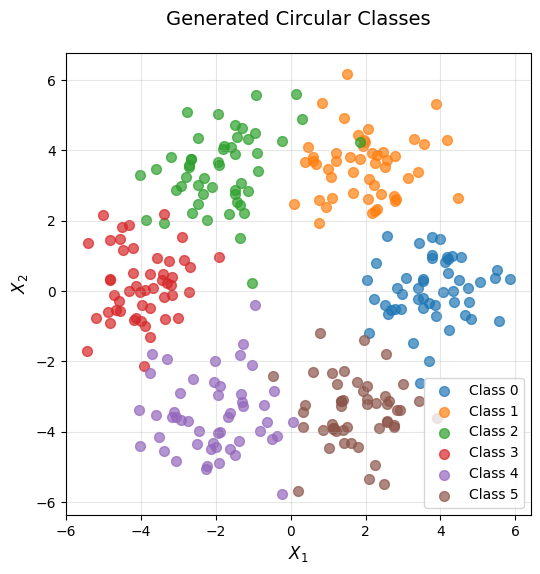

Generated 6 classes
Total samples: 300
Samples per class: 50


In [ ]:
def generate_data(m=3, n_per_class=50, radius=5, spread=0.5, seed=42):
    """
    Generate synthetic data in circular classes.

    Args:
        m (int): Number of classes
        n_per_class (int): Number of samples per class
        radius (float): Distance of class centers from origin
        spread (float): Standard deviation within each class
        seed (int): Random seed for reproducibility

    Returns:
        tuple: (X, labels) - features and class labels
    """
    np.random.seed(seed)
    X = []
    labels = []

    # Create classes at equal angles around a circle
    for i in range(m):
        # Calculate class center position
        angle = 2 * np.pi * i / m
        center_x = radius * np.cos(angle)
        center_y = radius * np.sin(angle)

        # Generate points around the class center
        x1 = np.random.normal(center_x, spread, n_per_class)
        x2 = np.random.normal(center_y, spread, n_per_class)

        X.append(np.column_stack((x1, x2)))
        labels.append(np.full(n_per_class, i))

    # Combine all classes
    X = np.vstack(X)
    labels = np.concatenate(labels)
    return X, labels

# Generate synthetic circular class data
X, labels = generate_data(m=6, n_per_class=50, radius=4, spread=1)

# Create visualization
plt.figure(figsize=(6, 6))
colors = plt.colormaps.get_cmap('tab10')

# Plot each class with different colors
for label in np.unique(labels):
    mask = (labels == label)
    plt.scatter(X[mask, 0], X[mask, 1], label=f'Class {label}', color=colors(label), alpha=0.7, s=50)

# Customize the plot
plt.title("Generated Circular Classes", fontsize=14, pad=20)
plt.xlabel("$X_1$", fontsize=12)
plt.ylabel("$X_2$", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print dataset information
print(f"Generated {len(np.unique(labels))} classes")
print(f"Total samples: {len(X)}")
print(f"Samples per class: {len(X) // len(np.unique(labels))}")

Training samples: 240
Testing samples: 60


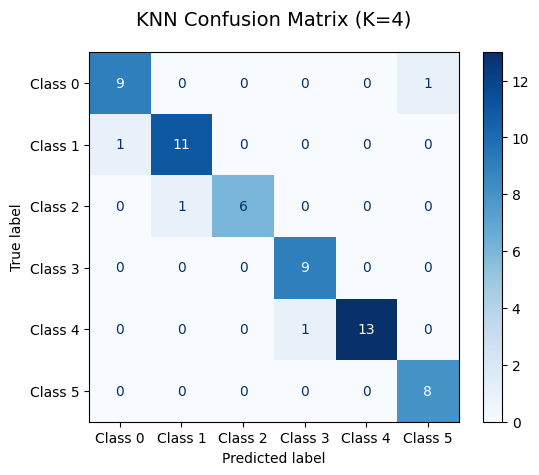


Classification Metrics (K=4):
Class 0:
  Sensitivity (Recall): 0.900
  Specificity:          0.980
  Precision:            0.900
------------------------------
Class 1:
  Sensitivity (Recall): 0.917
  Specificity:          0.979
  Precision:            0.917
------------------------------
Class 2:
  Sensitivity (Recall): 0.857
  Specificity:          1.000
  Precision:            1.000
------------------------------
Class 3:
  Sensitivity (Recall): 1.000
  Specificity:          0.980
  Precision:            0.900
------------------------------
Class 4:
  Sensitivity (Recall): 0.929
  Specificity:          1.000
  Precision:            1.000
------------------------------
Class 5:
  Sensitivity (Recall): 1.000
  Specificity:          0.981
  Precision:            0.889
------------------------------

Overall Performance:
Macro Precision: 0.934
Macro Recall:    0.934
Macro F1-Score:  0.934
Overall Accuracy: 0.933 (93.3%)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Set k value for KNN algorithm
k_value = 4

# Make predictions using KNN on test set
predictions = []

for sample in X_test:
    # Predict class for each test sample
    pred = knn(X_train, y_train, sample, k=k_value)
    predictions.append(pred)

predictions = np.array(predictions)

# Compute confusion matrix
cm = confusion_matrix(y_test, predictions)

# Plot confusion matrix with better styling
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'Class {i}' for i in range(6)])
disp.plot(cmap='Blues')
plt.title(f'KNN Confusion Matrix (K={k_value})', fontsize=14, pad=20)
plt.show()

# Calculate classification metrics for each class
print(f"\nClassification Metrics (k={k_value}):")
print("=" * 50)

num_classes = cm.shape[0]
precisions = []
recalls = []

for i in range(num_classes):
    # Calculate True/False Positives/Negatives for class i
    TP = cm[i, i]                           # True Positives: diagonal element
    FN = np.sum(cm[i, :]) - TP              # False Negatives: row sum minus TP
    FP = np.sum(cm[:, i]) - TP              # False Positives: column sum minus TP
    TN = np.sum(cm) - (TP + FP + FN)        # True Negatives: everything else

    # Calculate metrics (handle division by zero)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

    # Store for macro averages
    precisions.append(precision)
    recalls.append(sensitivity)

    # Display metrics for current class
    print(f"Class {i}:")
    print(f"  Sensitivity (Recall): {sensitivity:.3f}")
    print(f"  Specificity:          {specificity:.3f}")
    print(f"  Precision:            {precision:.3f}")
    print("-" * 30)

# Calculate macro averages (unweighted mean across all classes)
macro_precision = np.mean(precisions)
macro_recall = np.mean(recalls)
macro_f1 = 2 * (macro_precision * macro_recall) / (macro_precision + macro_recall) if (macro_precision + macro_recall) > 0 else 0

print(f"\nOverall Performance:")
print(f"Macro Precision: {macro_precision:.3f}")
print(f"Macro Recall:    {macro_recall:.3f}")
print(f"Macro F1-Score:  {macro_f1:.3f}")

# Calculate overall accuracy
accuracy = np.trace(cm) / np.sum(cm)
print(f"Overall Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

## **Decision Boundaries In KNN**

One of the unique features of k-Nearest Neighbors is that it **does not learn a fixed function or parameterized boundary during training**. Instead, it directly uses the training data to decide which label to assign to a new input.  
Because of this, the shape of the decision boundary in KNN can be **highly non-linear** and very flexible — it can twist and turn to follow the exact distribution of the data.

The **choice of `k`** controls this behavior:
- If **`k` is very small** (e.g., 1), the model can become too sensitive to noise and outliers in the training data. This means the decision boundary can be extremely jagged, trying to perfectly fit every training point — resulting in **overfitting**. The model memorizes the training samples and often performs poorly on unseen data.
- If **`k` is big**, the model starts to average over more neighbors. This makes the decision boundary **smoother**, but if `k` is too large, it might **underfit** the true structure — it misses subtle but real patterns in the data and treats all regions too similarly.

Because KNN always relies on comparing to **real stored samples**, the shape of its boundaries depends entirely on the data distribution. This makes KNN very powerful for complex, irregular regions but also sensitive to:
- **Outliers** (especially with small `k`),
- **Noisy or irrelevant features**,
- **Imbalanced classes**, where one class has many more samples.

In summary, KNN creates **flexible, data-driven decision boundaries**, but its performance depends heavily on the **right choice of `k`**, the **distance metric**, and **good feature scaling**.  

> *Always visualize the decision surface when you can — it’s the best way to see how well your KNN is balancing underfitting and overfitting!*

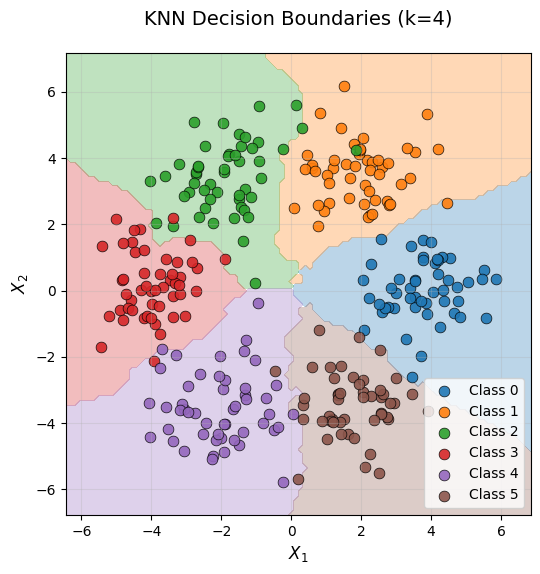

In [ ]:
k = 4
resolution = 100

# Create a mesh grid covering the data range
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, resolution),
    np.linspace(y_min, y_max, resolution)
)

# Create grid points for prediction
grid_points = np.column_stack([xx.ravel(), yy.ravel()])

# Predict class for each grid point using KNN
grid_predictions = []
for i, point in enumerate(grid_points):
    pred = knn(X, labels, point, k=k)
    grid_predictions.append(pred)
grid_predictions = np.array(grid_predictions).reshape(xx.shape)

# Create the plot
plt.figure(figsize=(6, 6))

# Plot decision regions with colored surfaces
colormap = plt.colormaps.get_cmap('tab10')
unique_labels = np.unique(labels)

# Create colored regions for each class
for label in unique_labels:
    # Create mask for current class regions
    class_mask = (grid_predictions == label)
    if np.any(class_mask):
        plt.contourf(xx, yy, class_mask.astype(int), levels=[0.5, 1.5], colors=[colormap(label)], alpha=0.3)

# Plot original data points
for label in unique_labels:
    mask = (labels == label)
    plt.scatter(X[mask, 0], X[mask, 1], label=f'Class {label}', color=colormap(label),s=60, alpha=0.9, edgecolors='black', linewidth=0.5)

# Customize the plot
plt.title(f'KNN Decision Boundaries (k={k})', fontsize=14, pad=20)
plt.xlabel("$X_1$", fontsize=12)
plt.ylabel("$X_2$", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **KNN on Diabetes Dataset**

The dataset we are working with here is the **Diabetes dataset** from `scikit-learn` which is a **regression dataset**. The goal is to predict a **continuous value** that represents a quantitative measure of disease progression one year after baseline measurements.  

This dataset contains **442 samples** with **10 standardized features** (like age, sex, BMI, blood pressure, and various blood serum measurements). Since the features have already been normalized by scikit-learn, we don’t need to apply additional scaling before using distance-based models like KNN.  

Unlike binary classification, where the output is either `0` or `1`, here the target values are continuous numbers.  
So in **k-Nearest Neighbors (KNN)**:  
- For classification, we would take the **majority vote** among the `k` nearest neighbors.  
- For regression, as in this dataset, we take the **mean value** of the targets of the `k` nearest neighbors.  

---

### **Why Can’t We Visualize It?**  
In simple 2D examples of KNN, we can draw the data points and decision boundaries. But here, since the Diabetes dataset has **10 input dimensions**, it’s impossible to directly visualize how neighbors are chosen.  
Instead, we rely on distance computations (Euclidean distance by default) in high-dimensional space to find which training samples are closest to the test sample.  

---

### **The Elbow Technique**  
To choose an appropriate `k`, we can use the **elbow method**.  

The idea is simple:  
1. Try multiple values of `k`.  
2. For regression, calculate the **loss (MSE)** for each value.  
   For classification, count the number of misclassified points.  
3. Plot the error vs. `k`.  

We will observe that:  
- In the beginning, increasing `k` rapidly reduces the error.  
- At some point, further increases in `k` yield diminishing returns — the error curve flattens and forms an **elbow shape**.  
- That **elbow point** (`k = 5` in the implementation below) is usually the best tradeoff, giving us a model that generalizes well without overfitting or underfitting.  

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Dataset shape: (442, 10)

Train samples: 353
Test samples: 89


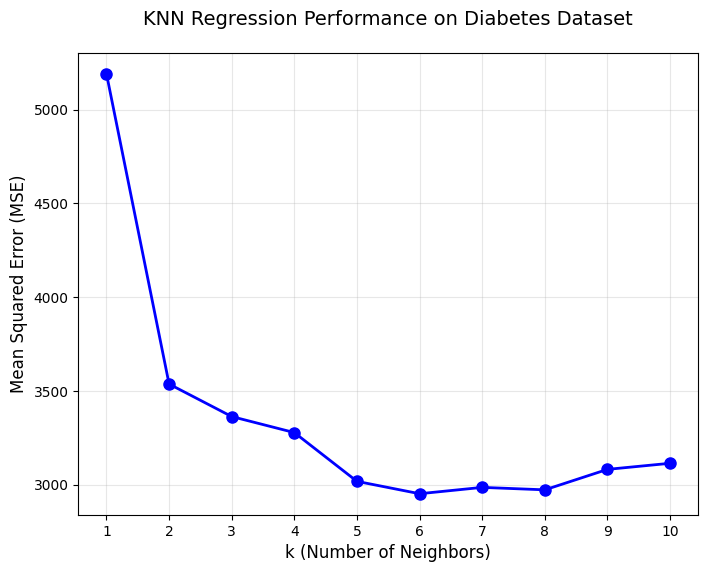

In [ ]:
from sklearn.datasets import load_diabetes

# Load diabetes dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y
display(df.head(5))

# Print dataset information
print(f"Dataset shape: {X.shape}")
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTrain samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Test different k values for KNN regression
max_k = 10
mse_list = []

for k in range(1, max_k + 1):
    # Make predictions for all test samples
    predictions = []
    for sample in X_test:
        pred = knn(X_train, y_train, sample, k=k, mode='regressor')
        predictions.append(pred)

    predictions = np.array(predictions)

    # Calculate Mean Squared Error
    mse = np.mean((y_test - predictions) ** 2)
    mse_list.append(mse)

# Plot MSE vs K
plt.figure(figsize=(8, 6))
plt.plot(range(1, max_k + 1), mse_list, linewidth=2, marker='o', markersize=8, color='blue')

# Customize the plot
plt.title('KNN Regression Performance on Diabetes Dataset', fontsize=14, pad=20)
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.xticks(range(1, max_k + 1))
plt.grid(True, alpha=0.3)
plt.show()

## **Limitations of KNN**

At first glance, **k-Nearest Neighbors (KNN)** looks like the perfect algorithm. It’s extremely simple, it works for both **classification** and **regression**, and it doesn’t even require a training phase. So you might wonder: *why do we spend so much time learning complicated parametric models like Logistic Regression, Linear Regression, or even Neural Networks, when we already have KNN?*  

The truth is that KNN has several **serious limitations** that make it impractical for most real-world problems:

---

### 1. **Computationally Expensive**
KNN doesn’t build a model in advance — it simply stores the whole dataset.  
So when a new data point arrives, the algorithm must compute its distance to **every single training sample**.  
- If you have **1 million samples** with **50 features** each, classifying just one new point requires computing 50 million distance calculations.  
- Parametric models, on the other hand, pre-learn weights, and prediction is just a matter of multiplying those weights by the input — a far cheaper computation.

---

### 2. **Storage Problem**
Because KNN has no training phase, it needs to **keep the entire dataset** in memory.  
This makes it very costly in terms of storage, especially when datasets are huge.  
- Imagine trying to run KNN on all of ImageNet (millions of high-dimensional images). Just storing and searching through them is impractical.

---

### 3. **The Curse of Dimensionality**
KNN relies on the concept of **distance**. But in high dimensions, distance loses its meaning:  
- In low dimensions (2D or 3D), "nearest neighbors" are intuitive — points close to each other are genuinely similar.  
- In high dimensions (say 100+ features), every point tends to be **almost equally far** from every other point. This makes the idea of "nearest" meaningless and the algorithm unstable.  

*Example:* If you measure similarity between people based on **height, weight, and age**, KNN works well. But if you add 100 irrelevant features (like "favorite color" or "shoe size on birthdays"), distance becomes noisy, and truly similar people may no longer appear close in feature space.

---

### 4. **Not Robust to Noise**
KNN is easily misled by noisy or mislabeled points.  
- If one mislabeled "cat" is sitting among many "dogs", a nearby test sample might get wrongly classified as "cat" just because of that one noisy neighbor.  
Parametric models tend to smooth out such noise by learning generalizable patterns.

---

### 5. **Poor with Imbalanced Data**
If one class heavily outnumbers the others, KNN will naturally favor the majority class because neighbors are more likely to come from it.  
- *Example:* In a medical dataset with 95% healthy patients and 5% sick patients, KNN might label almost everybody as "healthy" and still look accurate.

---

### **Bottom Line**
KNN is a beautiful and intuitive algorithm, perfect for teaching, small datasets, and problems with low dimensionality.  
But as soon as datasets grow in size, dimensionality, or complexity, its weaknesses become obvious — which is why we turn to **parametric models** like Logistic Regression, Linear Regression, or Neural Networks that are faster, more memory-efficient, and better suited for high-dimensional data.

## **Closing This Chapter**

In this chapter, we explored the world of **non-parametric models** through **k-Nearest Neighbors (KNN)** for both classification and regression problems.  
We saw how KNN relies on the idea of *similarity* rather than training parameters, and how its flexible decision boundaries can adapt to complex data shapes — but also why careful tuning of `k` is essential to avoid overfitting or underfitting, and how to do it using the **elbow method**.  

Along the way, we practiced visualizing decision regions, calculating performance metrics like **accuracy**, **precision**, **recall**, and **specificity**, and learned how confusion matrices help us understand model behavior, especially when we have more than two classes.

---

###🚀 **What’s Next?**

In the next chapter, we’ll take a big step forward into the powerful world of:

>**Ensemble Learning**

A strategy that combines multiple weak learners to build stronger models.  
Techniques like **Bagging**, **Boosting**, and **Random Forests** will show us how multiple models can work together to achieve higher accuracy, stability, and generalization than any single model alone.

Get ready to learn how **the wisdom of the crowd** can make our predictions smarter!